In [ ]:
from dowhy import CausalModel
from graphviz import Digraph
import pandas as pd
from pgmpy.estimators.CITests import chi_square
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### 1. Load dataset + examine

In [88]:
df = pd.read_csv('../data/software_usage_promotion.csv')

df['Combined Treatment'] = (df['Discount'] + 2*df['Tech Support']).astype('category')
df['Discount'] = df['Discount'].astype('int')
df['Tech Support'] = df['Discount'].astype('int')

In [89]:
df['Combined Treatment'].unique()

[1, 3, 2, 0]
Categories (4, int64): [0, 1, 2, 3]

### 2. Create DAG

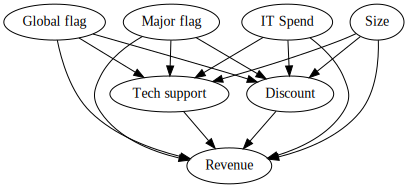

In [90]:
dot = Digraph(comment='Software Sales Causal DAG')

dot.node('G', 'Global flag')
dot.node('M', 'Major flag')
dot.node('IT', 'IT Spend')
dot.node('S', 'Size')
dot.node('T', 'Tech support')
dot.node('R', 'Revenue')
dot.node('D', 'Discount')

dot.edges([
    ('S', 'D'),
    ('S', 'R'),
    ('S', 'T'),
    ('IT', 'D'),
    ('IT', 'R'),
    ('IT', 'T'),
    ('G', 'D'),
    ('G', 'R'),
    ('G', 'T'),
    ('M', 'D'),
    ('M', 'R'),
    ('M', 'T'),
    ('D', 'R'),
    ('T', 'R')])

dot

Client company attributes cause both decisions to offer tech support and discount as well as revenue

### Sense-Check

In [91]:
#### Verify that company parameters & revenue aren't independent given tech support / discount

In [92]:
# convert revenue to bins
df['Revenue Binned'] = pd.cut(df.Revenue, 5)

In [ ]:
significance = 0.05
chi_square(X="Revenue Binned",
           Y="Global Flag",
           Z=["Discount", "Tech Support"],
           data=df,
           boolean=False,
           significance_level=significance)


In [ ]:
significance = 0.05
chi_square(X="Revenue Binned",
           Y="Global Flag",
           Z=[],
           data=df,
           boolean=False,
           significance_level=significance)

As we would expect, revenue and global flag aren't independent.
They're also not conditionally independent given Discount and tech support.

### 3. Create doWhy model

In [ ]:
confounders = [
    'Size', 'Employee Count', 'PC Count', 'IT Spend', 'Major Flag',
    'Global Flag', 'Commercial Flag', 'SMC Flag'
]

model = CausalModel(
    data=df.drop(columns=['Combined Treatment', 'Revenue Binned']),
    #treatment=['Discount'],
    treatment=['Discount', 'Tech Support'],
    #treatment=['Combined Treatment'],
    outcome='Revenue',
    common_causes=
    confounders
)

identified_estimand = model.identify_effect()

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['Discount', 'Tech Support'] on outcome ['Revenue']
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Number of general adjustment sets found: 1
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.


In [83]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[Revenue|Commercial Flag,Major Flag,IT Spend,Size,G ↪
d[Discount  Tech Support]                                                      ↪

↪                                              
↪ lobal Flag,SMC Flag,Employee Count,PC Count])
↪                                              
Estimand assumption 1, Unconfoundedness: If U→{Discount,Tech Support} and U→Revenue then P(Revenue|Discount,Tech Support,Commercial Flag,Major Flag,IT Spend,Size,Global Flag,SMC Flag,Employee Count,PC Count,U) = P(Revenue|Discount,Tech Support,Commercial Flag,Major Flag,IT Spend,Size,Global Flag,SMC Flag,Employee Count,PC Count)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: genera

In [84]:
tree_model = DecisionTreeClassifier(max_depth=5)

In [87]:
causal_estimate_reg = model.estimate_effect(
    identified_estimand=identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    control_value = (0,0),
    treatment_value=(1,1),
    target_units="ate",
    method_params=  {'init_params': {'model_y': GradientBoostingRegressor(),
                                   #'model_t': LogisticRegression(),
                                   'model_t': tree_model,
                                   'discrete_treatment': True},
                    'fit_params': {}
                    }
                        )

INFO:dowhy.causal_estimator:INFO: Using EconML Estimator
INFO:dowhy.causal_estimator:b: Revenue~Discount+Tech Support+Commercial Flag+Major Flag+IT Spend+Size+Global Flag+SMC Flag+Employee Count+PC Count | 


ValueError: Found input variables with inconsistent numbers of samples: [2000, 4000]

In [36]:
print(causal_estimate_reg)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[Revenue|Major Flag,IT Spend,Size,Global Flag,Employee  ↪
d[Combined Treatment]                                                          ↪

↪                 
↪ Count,PC Count])
↪                 
Estimand assumption 1, Unconfoundedness: If U→{Combined Treatment} and U→Revenue then P(Revenue|Combined Treatment,Major Flag,IT Spend,Size,Global Flag,Employee Count,PC Count,U) = P(Revenue|Combined Treatment,Major Flag,IT Spend,Size,Global Flag,Employee Count,PC Count)

## Realized estimand
b: Revenue~Combined Treatment+Major Flag+IT Spend+Size+Global Flag+Employee Count+PC Count | 
Target units: ate

## Estimate
Mean value: 3432.530837258362
Effect estimates: [[3432.53083726]]



In [38]:
df.describe()

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.202000,0.1950,0.504500,0.691000,28272.703000,61.115000,57.345500,113159.120000,0.503000,0.510500,15397.917422
std,0.401593,0.3963,0.500105,0.462197,28207.138885,53.449707,52.861123,100987.600092,0.500116,0.500015,11290.944451
min,0.000000,0.0000,0.000000,0.000000,1161.000000,10.000000,6.000000,10101.000000,0.000000,0.000000,-616.572451
25%,0.000000,0.0000,0.000000,0.000000,8914.000000,24.000000,22.000000,39282.000000,0.000000,0.000000,7545.052008
50%,0.000000,0.0000,1.000000,1.000000,19210.500000,44.000000,41.000000,81378.000000,1.000000,1.000000,12582.446440
75%,0.000000,0.0000,1.000000,1.000000,37991.500000,79.000000,74.000000,155635.000000,1.000000,1.000000,19662.979475
max,1.000000,1.0000,1.000000,1.000000,259808.000000,535.000000,407.000000,766485.000000,1.000000,1.000000,86006.924450


In [29]:
print(causal_estimate_reg.estimator.model.params)

const   -3371.561582
x1       5135.872925
x2       6819.175637
x3       1707.676414
x4          0.083730
x5         42.296115
x6         -0.019249
x7       4058.516407
x8          3.414931
dtype: float64
